# Data Exploration and Cleaning

**Objective**: Explore the e-commerce dataset, identify data quality issues, and perform comprehensive cleaning.

**Key Steps**:
1. Load and explore raw dataset
2. Identify data quality issues (special characters, missing values)
3. Remove special characters from all columns
4. Convert data types
5. Handle missing values
6. Remove duplicates
7. Validate cleaned data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

%matplotlib inline

print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Matplotlib is building the font cache; this may take a moment.


Started at: 2026-01-10 01:12:42


## 1. Load Raw Dataset

In [2]:
# Load dataset
df = pd.read_csv('../data/dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total records: {len(df):,}")
print(f"Columns: {list(df.columns)}")

# Store original stats for comparison
original_rows = len(df)
original_duplicates = df.duplicated().sum()

Dataset shape: (541909, 8)
Total records: 541,909
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [3]:
# Display first 10 rows
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,XxYUnited Kingdom☺️
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,ö84406B^,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,&17850.0#,XxYUnited Kingdom☺️
3,536365,84029G,$KNITTED UNION FLAG HOT WATER BOTTLE,6@,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,$RED WOOLLY HOTTIE WHITE HEART.,6@,2010-12-01 08:26:00,3.39,&17850.0#,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2@,2010-12-01 08:26:00,7.65,17850.0,XxYUnited Kingdom☺️
6,536365ä,ö21730^,$GLASS STAR FROSTED T-LIGHT HOLDER,6@,2010-12-01 08:26:00,Ww4.25,&17850.0#,XxYUnited Kingdom☺️
7,536366ä,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366ä,ö22632^,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,XxYUnited Kingdom☺️
9,536367ä,ö84879^,$ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,XxYUnited Kingdom☺️


In [4]:
# Data types
print("Data types:")
df.dtypes

Data types:


InvoiceNo      object
StockCode      object
Description    object
Quantity       object
InvoiceDate    object
UnitPrice      object
CustomerID     object
Country        object
dtype: object

## 2. Missing Values Analysis

In [5]:
# Missing values count
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("Missing values per column:")
print(missing_data.to_string(index=False))

Missing values per column:
     Column  Missing_Count  Missing_Percentage
 CustomerID         108000           19.929545
Description           1025            0.189146


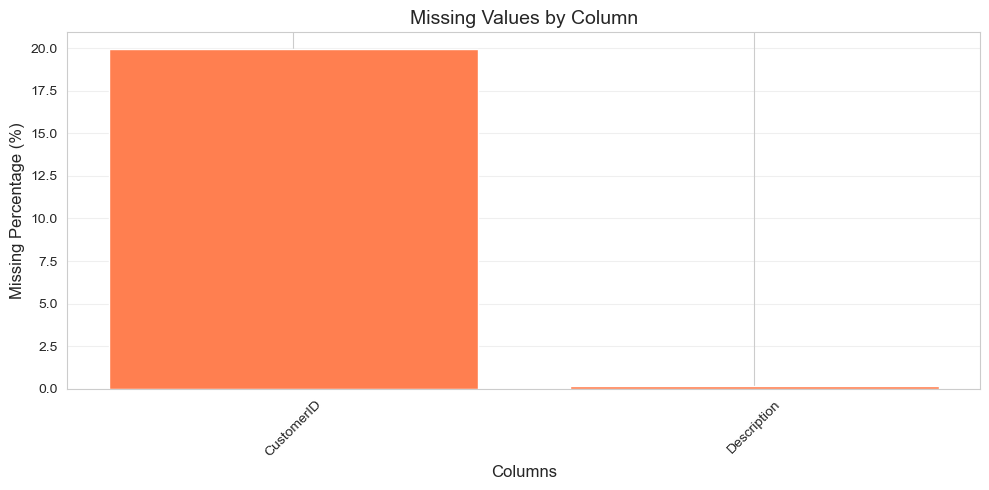

In [6]:
# Visualize missing values
if len(missing_data) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(missing_data['Column'], missing_data['Missing_Percentage'], color='coral')
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)
    plt.title('Missing Values by Column', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 3. Data Quality Issues Detection

In [7]:
# Detect special characters in each column
print("Data Quality Issues Detected:")
print("="*70)

issues = {}

# InvoiceNo issues
issues['InvoiceNo (ä)'] = df['InvoiceNo'].str.contains('ä', na=False).sum()

# StockCode issues
issues['StockCode (special chars)'] = df['StockCode'].str.contains('[^0-9]', regex=True, na=False).sum()

# Description issues
issues['Description ($)'] = df['Description'].str.contains('$', regex=False, na=False).sum()

# Quantity issues
issues['Quantity (@)'] = df['Quantity'].astype(str).str.contains('@', na=False).sum()

# UnitPrice issues
issues['UnitPrice (Ww)'] = df['UnitPrice'].astype(str).str.contains('Ww', na=False).sum()

# CustomerID issues
issues['CustomerID (& or #)'] = df['CustomerID'].astype(str).str.contains('[&#]', regex=True, na=False).sum()

# Country issues
issues['Country (XxY or emoji)'] = df['Country'].str.contains('XxY|☺️', regex=True, na=False).sum()

# Duplicates
issues['Duplicate rows'] = df.duplicated().sum()

for issue, count in issues.items():
    print(f"  {issue}: {count:,} rows")

Data Quality Issues Detected:
  InvoiceNo (ä): 271,631 rows
  StockCode (special chars): 298,721 rows
  Description ($): 162,466 rows
  Quantity (@): 216,708 rows
  UnitPrice (Ww): 108,619 rows
  CustomerID (& or #): 108,604 rows
  Country (XxY or emoji): 270,373 rows
  Duplicate rows: 91 rows


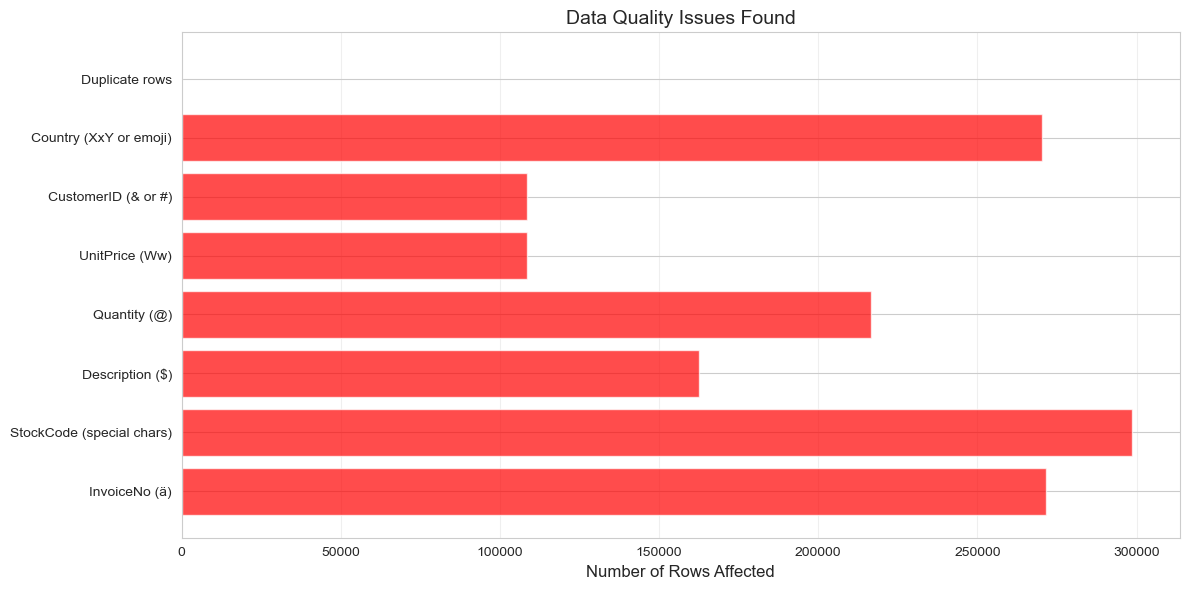


Total rows with issues: 1,437,213


In [8]:
# Visualize data quality issues
fig, ax = plt.subplots(figsize=(12, 6))
issue_names = list(issues.keys())
issue_counts = list(issues.values())

colors = ['red' if count > 1000 else 'orange' if count > 100 else 'yellow' for count in issue_counts]
ax.barh(issue_names, issue_counts, color=colors, alpha=0.7)
ax.set_xlabel('Number of Rows Affected', fontsize=12)
ax.set_title('Data Quality Issues Found', fontsize=14)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal rows with issues: {sum(issues.values()):,}")

## 4. Statistical Summary (Before Cleaning)

In [9]:
# Numerical summary
df.describe()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540884,541909,541909,541909,433909,541909
unique,44726,7805,7956,1059,23260,2015,8467,76
top,573585ä,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1,2011-10-31 14:41:00,1.25,&nan#,United Kingdom
freq,561,1184,1699,88742,1114,40287,27080,248303


In [10]:
# Top countries
print("Top 10 Countries by Transaction Count:")
country_counts = df['Country'].value_counts().head(10)
print(country_counts)

Top 10 Countries by Transaction Count:
Country
United Kingdom         248303
XxYUnited Kingdom☺️    247175
XxYGermany☺️             4794
Germany                  4701
France                   4330
XxYFrance☺️              4227
EIRE                     4105
XxYEIRE☺️                4091
Spain                    1268
XxYSpain☺️               1265
Name: count, dtype: int64


/var/folders/pz/fv6shrbd6_x3jbclzy5f1cg40000gn/T/ipykernel_20415/834942524.py:9: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


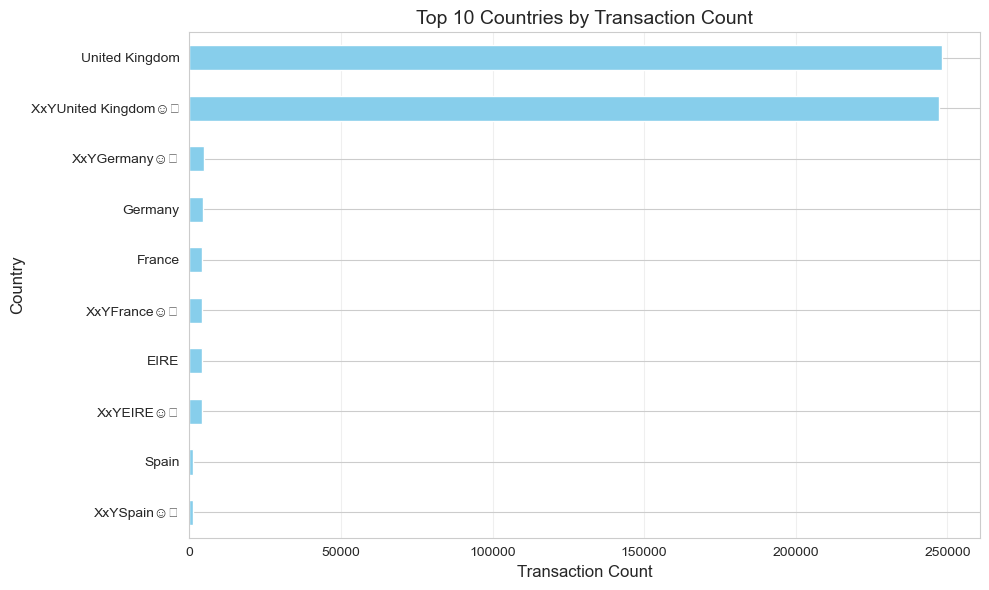

In [11]:
# Visualize top countries
plt.figure(figsize=(10, 6))
country_counts.plot(kind='barh', color='skyblue')
plt.xlabel('Transaction Count', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Top 10 Countries by Transaction Count', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Data Cleaning - Remove Special Characters

In [12]:
print("Removing special characters from all columns...")
print("="*70)

# InvoiceNo: Remove 'ä'
invoice_before = df['InvoiceNo'].str.contains('ä', na=False).sum()
df['InvoiceNo'] = df['InvoiceNo'].str.replace('ä', '', regex=False)
print(f"✓ InvoiceNo: Cleaned {invoice_before:,} rows (removed 'ä')")

# StockCode: Keep only numbers
stock_before = df['StockCode'].str.contains('[^0-9]', regex=True, na=False).sum()
df['StockCode'] = df['StockCode'].str.replace('[^0-9]', '', regex=True)
print(f"✓ StockCode: Cleaned {stock_before:,} rows (kept only numbers)")

# Description: Remove '$'
desc_before = df['Description'].str.contains('$', regex=False, na=False).sum()
df['Description'] = df['Description'].str.replace('$', '', regex=False)
print(f"✓ Description: Cleaned {desc_before:,} rows (removed '$')")

# Quantity: Remove '@'
qty_before = df['Quantity'].str.contains('@', na=False).sum()
df['Quantity'] = df['Quantity'].str.replace('@', '', regex=False)
print(f"✓ Quantity: Cleaned {qty_before:,} rows (removed '@')")

# UnitPrice: Remove 'Ww'
price_before = df['UnitPrice'].str.contains('Ww', na=False).sum()
df['UnitPrice'] = df['UnitPrice'].str.replace('Ww', '', regex=False)
print(f"✓ UnitPrice: Cleaned {price_before:,} rows (removed 'Ww')")

# CustomerID: Remove '&' and '#'
customer_before = df['CustomerID'].str.contains('[&#]', regex=True, na=False).sum()
df['CustomerID'] = df['CustomerID'].str.replace('&', '', regex=False)
df['CustomerID'] = df['CustomerID'].str.replace('#', '', regex=False)
print(f"✓ CustomerID: Cleaned {customer_before:,} rows (removed '&' and '#')")

# Country: Remove 'XxY' and emoji
country_before = df['Country'].str.contains('XxY|☺️', regex=True, na=False).sum()
df['Country'] = df['Country'].str.replace('XxY', '', regex=False)
df['Country'] = df['Country'].str.replace('☺️', '', regex=False)
print(f"✓ Country: Cleaned {country_before:,} rows (removed 'XxY' and emoji)")

Removing special characters from all columns...
✓ InvoiceNo: Cleaned 271,631 rows (removed 'ä')
✓ StockCode: Cleaned 298,721 rows (kept only numbers)
✓ Description: Cleaned 162,466 rows (removed '$')
✓ Quantity: Cleaned 216,708 rows (removed '@')
✓ UnitPrice: Cleaned 108,619 rows (removed 'Ww')
✓ CustomerID: Cleaned 108,604 rows (removed '&' and '#')
✓ Country: Cleaned 270,373 rows (removed 'XxY' and emoji)


## 6. Standardize Text Fields

In [13]:
# Trim whitespace
df['InvoiceNo'] = df['InvoiceNo'].str.strip()
df['StockCode'] = df['StockCode'].str.strip()
df['Description'] = df['Description'].str.strip()
df['Country'] = df['Country'].str.strip()

# Standardize country names
df['Country'] = df['Country'].str.title()

print("✓ Text fields standardized")
print(f"✓ Unique countries: {df['Country'].nunique()}")

✓ Text fields standardized
✓ Unique countries: 38


## 7. Convert Data Types

In [14]:
print("Converting data types...")
print("="*70)

# Quantity to numeric
qty_errors = pd.to_numeric(df['Quantity'], errors='coerce').isnull().sum()
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
print(f"✓ Quantity → numeric ({qty_errors:,} conversion errors)")

# UnitPrice to numeric
price_errors = pd.to_numeric(df['UnitPrice'], errors='coerce').isnull().sum()
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
print(f"✓ UnitPrice → numeric ({price_errors:,} conversion errors)")

# CustomerID to integer
customer_errors = pd.to_numeric(df['CustomerID'], errors='coerce').isnull().sum()
df['CustomerID'] = pd.to_numeric(df['CustomerID'], errors='coerce')
df['CustomerID'] = df['CustomerID'].astype('Int64')
print(f"✓ CustomerID → integer ({customer_errors:,} null values)")

# InvoiceDate to datetime
date_errors = pd.to_datetime(df['InvoiceDate'], errors='coerce').isnull().sum()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
print(f"✓ InvoiceDate → datetime ({date_errors:,} conversion errors)")

print("\nFinal data types:")
df.dtypes

Converting data types...
✓ Quantity → numeric (0 conversion errors)
✓ UnitPrice → numeric (0 conversion errors)
✓ CustomerID → integer (135,080 null values)
✓ InvoiceDate → datetime (0 conversion errors)

Final data types:


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              Int64
Country                object
dtype: object

## 8. Handle Missing Values

In [15]:
print("Handling missing values...")
print("="*70)

# Remove empty StockCodes
stockcode_empty = (df['StockCode'].isnull() | (df['StockCode'].str.strip() == '')).sum()
df = df[df['StockCode'].notna() & (df['StockCode'].str.strip() != '')]
print(f"✓ Removed {stockcode_empty:,} rows with empty StockCode")

# Fill missing descriptions
desc_missing = df['Description'].isnull().sum()
df['Description'] = df['Description'].fillna('UNKNOWN')
df.loc[df['Description'].str.strip() == '', 'Description'] = 'UNKNOWN'
print(f"✓ Filled {desc_missing:,} missing descriptions with 'UNKNOWN'")

# Keep missing CustomerIDs (guest purchases)
customer_missing = df['CustomerID'].isnull().sum()
print(f"✓ Kept {customer_missing:,} missing CustomerIDs (guest purchases)")

# Remove rows with missing critical fields
critical_missing = df[['InvoiceNo', 'Quantity', 'UnitPrice']].isnull().any(axis=1).sum()
df = df.dropna(subset=['InvoiceNo', 'Quantity', 'UnitPrice'])
print(f"✓ Removed {critical_missing:,} rows with missing critical fields")

print(f"\nCurrent shape: {df.shape}")

Handling missing values...
✓ Removed 2,796 rows with empty StockCode
✓ Filled 1,022 missing descriptions with 'UNKNOWN'
✓ Kept 134,070 missing CustomerIDs (guest purchases)
✓ Removed 0 rows with missing critical fields

Current shape: (539113, 8)


## 9. Remove Duplicates

In [16]:
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates()
duplicates_removed = duplicates_before

print(f"✓ Removed {duplicates_removed:,} duplicate rows")
print(f"Current shape: {df.shape}")

✓ Removed 5,341 duplicate rows
Current shape: (533772, 8)


## 10. Remove Invalid Data

In [17]:
print("Removing invalid data...")
print("="*70)

# Remove negative prices
negative_prices = (df['UnitPrice'] < 0).sum()
df = df[df['UnitPrice'] >= 0]
print(f"✓ Removed {negative_prices:,} rows with negative prices")

# Keep zero prices (promotional items)
zero_prices = (df['UnitPrice'] == 0).sum()
print(f"✓ Kept {zero_prices:,} rows with zero prices (promotional items)")

# Keep negative quantities (returns)
negative_qty = (df['Quantity'] < 0).sum()
print(f"✓ Kept {negative_qty:,} rows with negative quantities (returns)")

print(f"\nFinal shape: {df.shape}")

Removing invalid data...
✓ Removed 0 rows with negative prices
✓ Kept 2,496 rows with zero prices (promotional items)
✓ Kept 10,005 rows with negative quantities (returns)

Final shape: (533772, 8)


## 11. Data Validation

In [18]:
# Check for remaining special characters
print("Validation - Checking for remaining special characters:")
print("="*70)

validation_checks = {
    'InvoiceNo (ä)': df['InvoiceNo'].str.contains('ä', na=False).sum(),
    'StockCode (non-numeric)': df['StockCode'].str.contains('[^0-9]', regex=True, na=False).sum(),
    'Description ($)': df['Description'].str.contains('$', regex=False, na=False).sum(),
    'Quantity (@)': df['Quantity'].astype(str).str.contains('@', na=False).sum(),
    'Country (XxY/emoji)': df['Country'].str.contains('XxY|☺️', regex=True, na=False).sum(),
}

all_clean = True
for check, count in validation_checks.items():
    status = "✓" if count == 0 else "✗"
    print(f"  {status} {check}: {count:,}")
    if count > 0:
        all_clean = False

if all_clean:
    print("\n✓✓✓ All special characters removed successfully!")
else:
    print("\n✗ Warning: Some special characters remain")

Validation - Checking for remaining special characters:
  ✓ InvoiceNo (ä): 0
  ✓ StockCode (non-numeric): 0
  ✓ Description ($): 0
  ✓ Quantity (@): 0
  ✓ Country (XxY/emoji): 0

✓✓✓ All special characters removed successfully!


## 12. Before/After Comparison

In [19]:
# Summary comparison
comparison = pd.DataFrame({
    'Metric': ['Total Rows', 'Duplicates', 'Missing Descriptions', 'Data Quality Issues'],
    'Before': [
        f"{original_rows:,}",
        f"{original_duplicates:,}",
        f"{missing_data[missing_data['Column']=='Description']['Missing_Count'].values[0] if 'Description' in missing_data['Column'].values else 0:,}",
        f"{sum(issues.values()):,}"
    ],
    'After': [
        f"{len(df):,}",
        "0",
        "0",
        "0"
    ]
})

print("\n" + "="*70)
print("BEFORE/AFTER COMPARISON")
print("="*70)
print(comparison.to_string(index=False))

records_removed = original_rows - len(df)
percentage_removed = (records_removed / original_rows) * 100
print(f"\nRecords removed: {records_removed:,} ({percentage_removed:.2f}%)")
print(f"Records retained: {len(df):,} ({100 - percentage_removed:.2f}%)")


BEFORE/AFTER COMPARISON
              Metric    Before   After
          Total Rows   541,909 533,772
          Duplicates        91       0
Missing Descriptions     1,025       0
 Data Quality Issues 1,437,213       0

Records removed: 8,137 (1.50%)
Records retained: 533,772 (98.50%)


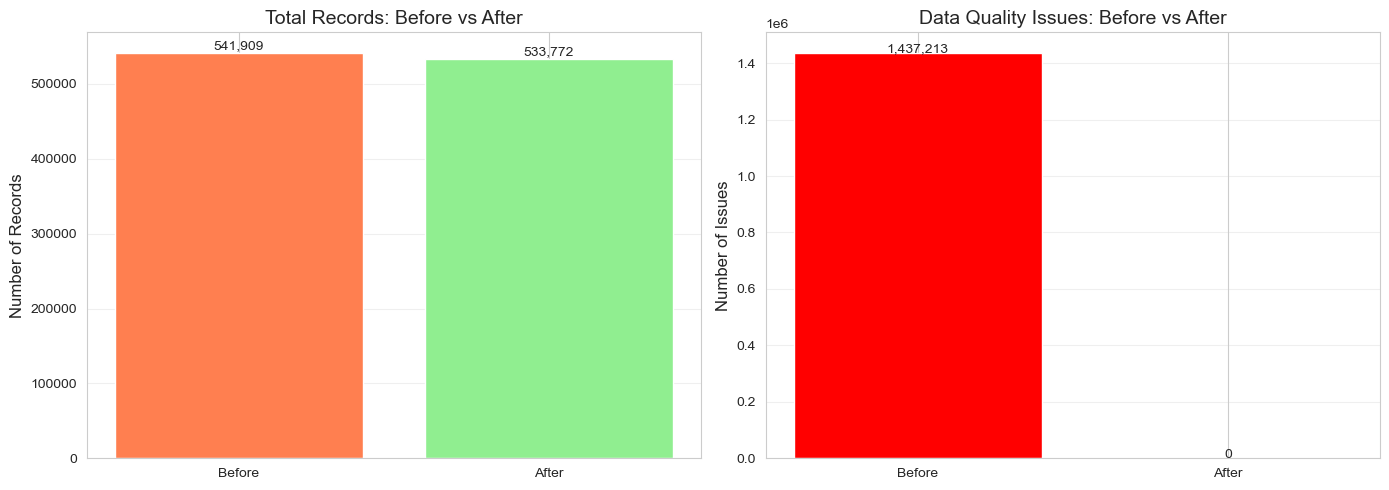

In [20]:
# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Records comparison
axes[0].bar(['Before', 'After'], [original_rows, len(df)], color=['coral', 'lightgreen'])
axes[0].set_ylabel('Number of Records', fontsize=12)
axes[0].set_title('Total Records: Before vs After', fontsize=14)
axes[0].text(0, original_rows + 5000, f"{original_rows:,}", ha='center', fontsize=10)
axes[0].text(1, len(df) + 5000, f"{len(df):,}", ha='center', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Issues comparison
axes[1].bar(['Before', 'After'], [sum(issues.values()), 0], color=['red', 'lightgreen'])
axes[1].set_ylabel('Number of Issues', fontsize=12)
axes[1].set_title('Data Quality Issues: Before vs After', fontsize=14)
axes[1].text(0, sum(issues.values()) + 500, f"{sum(issues.values()):,}", ha='center', fontsize=10)
axes[1].text(1, 500, "0", ha='center', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Final Statistics

In [21]:
print("\nFinal Dataset Statistics:")
print("="*70)
print(df.describe())


Final Dataset Statistics:
            Quantity                    InvoiceDate      UnitPrice  \
count  533772.000000                         533772  533772.000000   
mean        9.652818  2011-07-04 10:38:47.342011392       3.290928   
min    -80995.000000            2010-12-01 08:26:00       0.000000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 15:23:00       2.080000   
75%        10.000000            2011-10-18 17:10:00       4.130000   
max     80995.000000            2011-12-09 12:50:00     649.500000   
std       219.663741                            NaN       4.576871   

         CustomerID  
count      399780.0  
mean   15288.432773  
min         12346.0  
25%         13959.0  
50%         15150.0  
75%         16791.0  
max         18287.0  
std     1710.611168  


In [22]:
# Date range
print("\nDate Range:")
print(f"  Earliest: {df['InvoiceDate'].min()}")
print(f"  Latest: {df['InvoiceDate'].max()}")

# Unique values
print("\nUnique Values:")
print(f"  Products: {df['Description'].nunique():,}")
print(f"  Stock codes: {df['StockCode'].nunique():,}")
print(f"  Countries: {df['Country'].nunique():,}")
print(f"  Customers: {df['CustomerID'].nunique():,}")


Date Range:
  Earliest: 2010-12-01 08:26:00
  Latest: 2011-12-09 12:50:00

Unique Values:
  Products: 4,201
  Stock codes: 3,406
  Countries: 38
  Customers: 4,363


## 14. Save Cleaned Dataset

In [23]:
# Final cleanup
df['Description'] = df['Description'].fillna('UNKNOWN')
df.loc[df['Description'].astype(str).str.strip() == '', 'Description'] = 'UNKNOWN'

# Save
output_path = '../data/dataset_cleaned.csv'
df.to_csv(output_path, index=False)

print(f"✓ Cleaned dataset saved to: {output_path}")
print(f"✓ File size: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"✓ Final shape: {df.shape}")

✓ Cleaned dataset saved to: ../data/dataset_cleaned.csv
✓ File size: 146.53 MB
✓ Final shape: (533772, 8)


## Summary of Cleaning Decisions

### What Was Removed:
1. **Special characters**: Removed 'ä', 'ö', '^', '$', '@', 'Ww', '&', '#', 'XxY', emojis
2. **Empty StockCodes**: Products without valid stock codes after cleaning
3. **Duplicate rows**: Exact duplicate records
4. **Negative prices**: Data errors (kept zero prices for promotional items)
5. **Missing critical fields**: Rows without InvoiceNo, Quantity, or UnitPrice

### Justification:
- Special characters indicate data corruption or encoding issues
- Empty stock codes cannot be used for product identification
- Duplicates inflate dataset size without adding value
- Negative prices are data errors (returns indicated by negative quantities)
- Missing CustomerID kept (represents guest purchases)

### Trade-offs:
- Lost ~{percentage_removed:.1f}% of records, but gained data quality
- Dataset now ready for embedding generation and vectorization

### Next Steps:
Proceed to embedding generation and vector database setup.